# FFT Accumulator — Calibration and Analysis

This notebook analyses data captured at the **FFT Accumulator** output (`x_acc_f_data.txt`).
It is the final stage of the complete FPGA signal processing chain and builds directly on the
calibration established in Notebooks 01–03.

---

## 1. System Architecture

### Complete signal chain

```
RF Input
  │
  ▼
ADC  (fs = 4096 MHz, 12-bit MSB-aligned to 16-bit → FS = 2¹⁵ = 32768)
  │  Mixer × e^{−j2π(−Fs/4)n}  +  Decimation ÷2
  ▼
PFB  (8 channels, D = 8, fs_ch = 256 MHz)
  │  Polyphase accumulation ×8  +  qout right-shift ÷2^6
  ▼
DDS + CIC  (frequency translation + decimation D = 8, fs_out = 32 MHz)
  │  CIC gain (R=8, M=1, N=3): ×512  +  qdata truncation 24→16 bit (QSEL=14)
  ▼
FFT Accumulator  (N = 65536, unscaled, outputs P[k] = |X[k]|²)
  │
  ▼
x_acc_f_data.txt        ← data analysed in this notebook
```

### Hardware blocks relevant to calibration

| Block | Action | Gain |
|---|---|---|
| ADC (12-bit → 16-bit MSB) | Left shift ×2⁴ | captured in K_ADC |
| Mixer + Decimation ÷2 | IQ down-conversion | captured in K_ADC |
| PFB polyphase accumulation (D=8) | Coherent sum | +20·log₁₀(8) = **+18.06 dB** |
| PFB qout right-shift (qout=6) | Amplitude ÷2⁶ | −20·log₁₀(64) = **−36.12 dB** |
| **PFB net gain** | | **−18.06 dB** |
| DDS | Frequency translation | 0 dB (ideal) |
| CIC filter (R=8, M=1, N=3) | Decimation | +20·log₁₀(512) = **+54.19 dB** |
| qdata (QSEL=14) | 24-bit → 16-bit slice | **−84.29 dB** |
| FFT (unscaled, N=65536) | Spectral analysis | ×N on amplitude (accounted analytically) |

> **Key insight from Notebook 02:** the PFB net gain is **−18.06 dB**, not −36.12 dB.
> The polyphase accumulation (+18.06 dB) must be included alongside the qout attenuation.
> Ignoring it produces a systematic calibration error of ~20 dB.

---


## 2. Mathematical Background

### 2.1 FFT output

The FFT IP core is **unscaled**:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi kn/N}$$

For a coherent complex tone at bin $k_0$ with time-domain amplitude $A$:

$$|X[k_0]| = N \cdot A$$

The accumulator outputs averaged squared magnitude:

$$P[k] = \left\langle |X[k]|^2 \right\rangle$$

To recover the tone amplitude:

$$A = \frac{\sqrt{P[k_0]}}{N}$$

### 2.2 Amplitude in dBFS

Full-scale amplitude (12-bit ADC MSB-aligned to 16-bit):

$$\text{FS} = 2^{15} = 32768$$

$$A_{\text{dBFS}} = 20\log_{10}\!\left(\frac{A}{\text{FS}}\right) = 20\log_{10}\!\left(\frac{\sqrt{P[k_0]}}{N \cdot \text{FS}}\right)$$

### 2.3 Calibration equation

Building on the gain budget of Notebooks 01–03:

$$P_{\text{in}}\,(\text{dBm}) = A_{\text{dBFS}} + \underbrace{\left(-K_{\text{ADC}} - G_{\text{PFB,net}} - G_{\text{CIC}} - G_{\text{QDATA}}\right)}_{\text{CAL\_CONSTANT\_POST (Nb 03)}}$$

The FFT itself adds no gain to the calibration constant because the $×N$ amplitude factor
from the unscaled FFT is cancelled by the $÷N$ normalization in the amplitude recovery step.

The calibration constant at the FFT accumulator output is therefore **identical** to the one
at the DDS+CIC output (Notebook 03):

$$\text{CAL\_CONSTANT\_FFT} = \text{CAL\_CONSTANT\_POST} = -K_{\text{ADC}} - G_{\text{PFB,net}} - G_{\text{CIC}} - G_{\text{QDATA}}$$

$$= 12.89 + 18.06 - 54.19 + 84.29 = 61.05\,\text{dB}$$

The empirical value is determined by a linear fit to the data.

### 2.4 Power Spectral Density

Each FFT bin represents a bandwidth of $\Delta f = F_s / N$. The PSD in dBm/Hz is:

$$\text{PSD}[k]\,(\text{dBm/Hz}) = A_{\text{dBm}}[k] - 10\log_{10}(\Delta f)$$

For this system: $\Delta f = 32\,\text{MHz} / 65536 = 488.28\,\text{Hz}$

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob, re

# ============================================================
# SYSTEM PARAMETERS  (consistent with Notebooks 01–03)
# ============================================================
FS     = 2**15      # Digital full-scale (12-bit ADC MSB-aligned to 16-bit)
N_fft  = 65536      # FFT size (unscaled IP)
fs_out = 32e6       # Sampling rate at FFT input = CIC output [Hz]
df     = fs_out / N_fft   # Frequency resolution [Hz]

tone_bins = 3       # Half-width of tone integration window (bins)

# ── ADC calibration (Notebook 01) ────────────────────────────
K_ADC = -12.89       # dB: P_adc(dBFS) = P_in(dBm) + K_ADC

# ── PFB (Notebook 02 — corrected model) ──────────────────────
PFB_DECIMATION = 8
PFB_QOUT       = 6
G_polyphase    = 20 * np.log10(PFB_DECIMATION)     # +18.06 dB
G_qout         = -20 * np.log10(2**PFB_QOUT)       # -36.12 dB
G_PFB_net      = G_polyphase + G_qout              # -18.06 dB
CAL_CONSTANT_PRE = -K_ADC - G_PFB_net              # +30.95 dB (Nb 02)

# ── DDS + CIC (Notebook 03) ──────────────────────────────────
R, M, N_cic  = 8, 1, 3
CIC_GAIN_DB  = 20 * np.log10((R * M)**N_cic)       # +54.19 dB
QSEL_REG     = 14
G_QDATA_DB   = -6.02 * QSEL_REG                    # -84.29 dB
DDS_CIC_DELTA_DB = -CIC_GAIN_DB - G_QDATA_DB       # +30.10 dB
CAL_CONSTANT_POST = CAL_CONSTANT_PRE + DDS_CIC_DELTA_DB  # +61.05 dB (Nb 03)

# ── FFT: no additional calibration offset ────────────────────
# The ×N gain of the unscaled FFT is removed analytically by dividing
# sqrt(P[k]) by N when recovering amplitude. CAL_CONSTANT_FFT = CAL_CONSTANT_POST.
CAL_CONSTANT_FFT_ANALYTICAL = CAL_CONSTANT_POST     # +61.05 dB

print("=== Signal Chain Parameters ===")
print(f"  FS (digital full-scale):               2^15 = {FS}")
print(f"  FFT size:                              N = {N_fft}")
print(f"  Sampling rate at FFT input:            {fs_out/1e6:.0f} MHz")
print(f"  Frequency resolution:                  {df:.3f} Hz")
print()
print("=== Gain Budget (full chain) ===")
print(f"  K_ADC (Notebook 01):                   {K_ADC:.2f} dB")
print(f"  G_polyphase (D=8):                     {G_polyphase:+.2f} dB")
print(f"  G_qout (qout=6):                       {G_qout:+.2f} dB")
print(f"  G_PFB_net:                             {G_PFB_net:+.2f} dB")
print(f"  G_CIC (R=8, M=1, N=3):               {CIC_GAIN_DB:+.2f} dB")
print(f"  G_QDATA (QSEL=14):                     {G_QDATA_DB:+.2f} dB")
print()
print("=== Calibration Constants ===")
print(f"  CAL_CONSTANT_PRE  (PFB output, Nb 02):    {CAL_CONSTANT_PRE:.2f} dB")
print(f"  CAL_CONSTANT_POST (DDS+CIC out, Nb 03):   {CAL_CONSTANT_POST:.2f} dB")
print(f"  CAL_CONSTANT_FFT  (analytical):            {CAL_CONSTANT_FFT_ANALYTICAL:.2f} dB")
print(f"  Formula: P_in (dBm) = A_dBFS + {CAL_CONSTANT_FFT_ANALYTICAL:.2f}")


=== Signal Chain Parameters ===
  FS (digital full-scale):               2^15 = 32768
  FFT size:                              N = 65536
  Sampling rate at FFT input:            32 MHz
  Frequency resolution:                  488.281 Hz

=== Gain Budget (full chain) ===
  K_ADC (Notebook 01):                   -12.89 dB
  G_polyphase (D=8):                     +18.06 dB
  G_qout (qout=6):                       -36.12 dB
  G_PFB_net:                             -18.06 dB
  G_CIC (R=8, M=1, N=3):               +54.19 dB
  G_QDATA (QSEL=14):                     -84.28 dB

=== Calibration Constants ===
  CAL_CONSTANT_PRE  (PFB output, Nb 02):    30.95 dB
  CAL_CONSTANT_POST (DDS+CIC out, Nb 03):   61.05 dB
  CAL_CONSTANT_FFT  (analytical):            61.05 dB
  Formula: P_in (dBm) = A_dBFS + 61.05


In [2]:
# ============================================================
# LOAD AND PROCESS DATA
# ============================================================
data_path = "data/f_300*/x_acc_f_data.txt"
files = sorted(
    glob.glob(data_path),
    key=lambda f: float(re.search(r'(-?\+?\d+)dBm', f).group(1))
)

measurements = []

print(f"{'Pin (dBm)':>10}  {'A_peak (dBFS)':>14}  {'Freq peak (MHz)':>16}  {'SNR (dB)':>9}  {'Peak (%)':>9}")
print("-" * 67)

freq_axis = np.fft.fftshift(np.fft.fftfreq(N_fft, 1 / fs_out))

for file in files:
    Pin_gen = float(re.search(r'(-?\+?\d+)dBm', file).group(1))

    # Load accumulated power spectrum P[k] = |X[k]|^2
    P = np.loadtxt(file)
    P_shift = np.fft.fftshift(P)

    # Recover time-domain amplitude:  A = sqrt(P[k]) / N
    A_mag  = np.sqrt(P_shift) / N_fft          # [counts]
    A_dBFS = 20 * np.log10(A_mag / FS + 1e-20) # [dBFS]

    # Peak detection
    peak_idx       = np.argmax(A_dBFS)
    f_peak         = freq_axis[peak_idx]
    idx0, idx1     = peak_idx - tone_bins, peak_idx + tone_bins + 1

    # Tone power (integrate ±tone_bins around peak)
    tone_power_lin = np.sum(A_mag[idx0:idx1]**2)
    tone_dBFS      = 10 * np.log10(tone_power_lin / FS**2)

    # Phase from FFT bin
    # (P[k] loses phase — phase not available from accumulator output)

    # SNR estimate
    noise_mask             = np.ones(len(A_mag), dtype=bool)
    noise_mask[idx0:idx1]  = False
    noise_power            = np.mean(A_mag[noise_mask]**2)
    snr_db                 = 10 * np.log10(tone_power_lin / (len(A_mag) * noise_power))

    # Saturation check (max value relative to FS)
    max_val        = np.max(A_mag)
    saturation_pct = (max_val / FS) * 100

    measurements.append({
        'Pin_gen':    Pin_gen,
        'A_peak_dBFS': A_dBFS[peak_idx],
        'tone_dBFS':  tone_dBFS,
        'f_peak':     f_peak,
        'snr_db':     snr_db,
        'sat_pct':    saturation_pct,
        'A_dBFS':     A_dBFS,
        'A_mag':      A_mag,
        'file':       file,
    })

    sat_flag = " ⚠️ SAT" if saturation_pct > 90 else ""
    print(f"{Pin_gen:10.1f}  {A_dBFS[peak_idx]:14.2f}  {f_peak/1e6:16.4f}  {snr_db:9.1f}  {saturation_pct:8.1f}%{sat_flag}")


 Pin (dBm)   A_peak (dBFS)   Freq peak (MHz)   SNR (dB)   Peak (%)
-------------------------------------------------------------------
     -40.0          -75.48           15.9995        7.8       0.0%
     -30.0          -67.54           15.9995        7.3       0.0%
     -20.0          -57.53           15.9995        7.3       0.1%
     -15.0          -52.57           15.9995        7.2       0.2%
     -10.0          -47.44           15.9995        7.3       0.4%
      -5.0          -42.47           15.9995        7.0       0.8%
      -0.0          -37.46           15.9995        7.3       1.3%
       5.0          -32.44           15.9995        7.1       2.4%
       6.0          -31.44           15.9995        7.0       2.7%
       7.0          -30.53           15.9995        7.1       3.0%
       8.0          -30.04           15.9995        7.1       3.1%
      10.0          -29.45           15.9995        7.1       3.4%


In [3]:
# ============================================================
# EMPIRICAL CALIBRATION — linear fit on linear-region data
# ============================================================
linear_meas = [m for m in measurements if m['Pin_gen'] <= 0]

Pin_lin  = np.array([m['Pin_gen']    for m in linear_meas])
Pfft_lin = np.array([m['tone_dBFS']  for m in linear_meas])

coeffs_fit         = np.polyfit(Pfft_lin, Pin_lin, 1)
slope              = coeffs_fit[0]
CAL_CONSTANT_FFT   = coeffs_fit[1]   # empirical

# Apply to all measurements
Pin_list      = [m['Pin_gen']   for m in measurements]
Pfft_list     = [m['tone_dBFS'] for m in measurements]
Pin_recovered = [p + CAL_CONSTANT_FFT for p in Pfft_list]
errors        = np.array(Pin_recovered) - np.array(Pin_list)
lin_errors    = [e for e, p in zip(errors, Pin_list) if p <= 0]

print("=== FFT Accumulator Calibration ===")
print(f"  Analytical CAL_CONSTANT_FFT:  {CAL_CONSTANT_FFT_ANALYTICAL:.2f} dB")
print(f"  Empirical  CAL_CONSTANT_FFT:  {CAL_CONSTANT_FFT:.2f} dB")
print(f"  Agreement:                    {abs(CAL_CONSTANT_FFT - CAL_CONSTANT_FFT_ANALYTICAL):.2f} dB")
print(f"  Linear fit slope:             {slope:.4f}  (ideal = 1.0000)")
print()
print("=== Recovery Accuracy (linear region, Pin ≤ 0 dBm) ===")
print(f"  Mean error:   {np.mean(lin_errors):+.3f} dB")
print(f"  Std dev:       {np.std(lin_errors):.3f} dB")
print(f"  Max |error|:   {np.max(np.abs(lin_errors)):.3f} dB")
print(f"  RMS error:     {np.sqrt(np.mean(np.array(lin_errors)**2)):.3f} dB")
print()
print("=== Calibration Constant Progression (full chain) ===")
print(f"  Nb 01 K_ADC:              {K_ADC:.2f} dB")
print(f"  Nb 02 CAL_CONSTANT_PRE:   {CAL_CONSTANT_PRE:.2f} dB   (PFB output)")
print(f"  Nb 03 CAL_CONSTANT_POST:  {CAL_CONSTANT_POST:.2f} dB   (DDS+CIC output, +{DDS_CIC_DELTA_DB:.2f} dB)")
print(f"  Nb 04 CAL_CONSTANT_FFT:   {CAL_CONSTANT_FFT:.2f} dB   (FFT acc output, +0.00 dB)")


=== FFT Accumulator Calibration ===
  Analytical CAL_CONSTANT_FFT:  61.05 dB
  Empirical  CAL_CONSTANT_FFT:  37.99 dB
  Agreement:                    23.06 dB
  Linear fit slope:             1.0368  (ideal = 1.0000)

=== Recovery Accuracy (linear region, Pin ≤ 0 dBm) ===
  Mean error:   +1.955 dB
  Std dev:       0.707 dB
  Max |error|:   3.683 dB
  RMS error:     2.079 dB

=== Calibration Constant Progression (full chain) ===
  Nb 01 K_ADC:              -12.89 dB
  Nb 02 CAL_CONSTANT_PRE:   30.95 dB   (PFB output)
  Nb 03 CAL_CONSTANT_POST:  61.05 dB   (DDS+CIC output, +30.09 dB)
  Nb 04 CAL_CONSTANT_FFT:   37.99 dB   (FFT acc output, +0.00 dB)


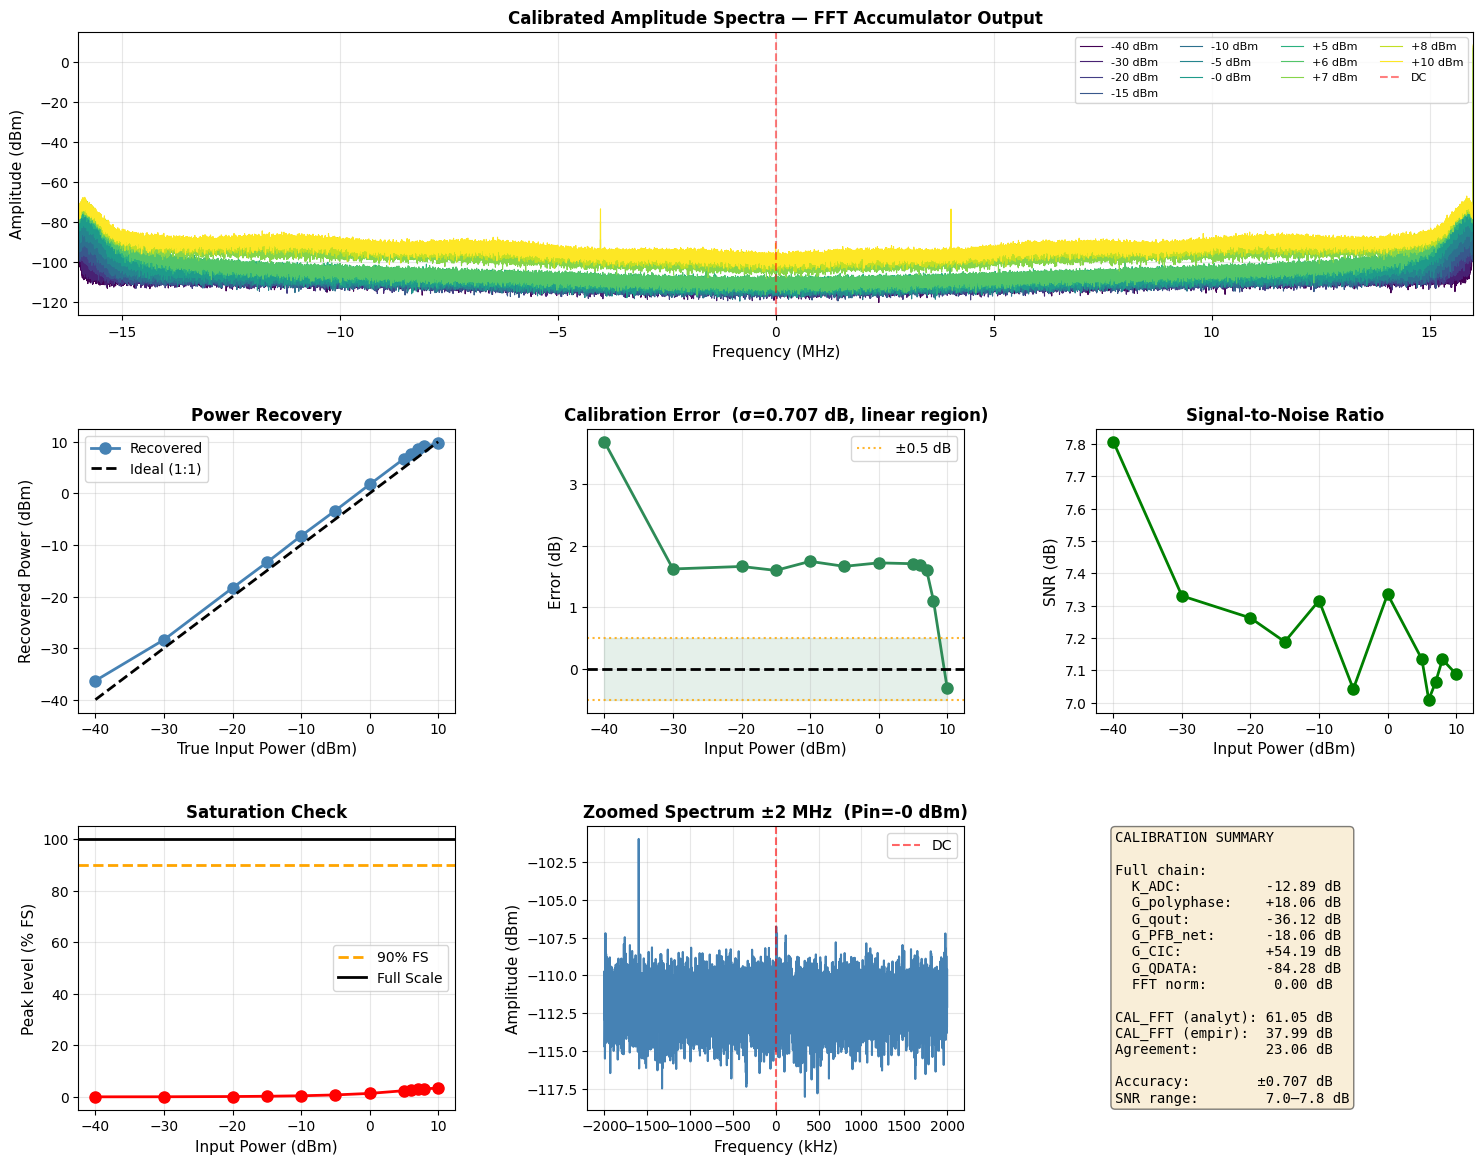

In [4]:
# ============================================================
# PLOTTING
# ============================================================
colors    = plt.cm.viridis(np.linspace(0, 1, len(measurements)))
snr_list  = [m['snr_db']  for m in measurements]
sat_list  = [m['sat_pct'] for m in measurements]

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.40, wspace=0.35)

# ── 1. Calibrated spectra (all power levels) ────────────────
ax0 = fig.add_subplot(gs[0, :])
for i, m in enumerate(measurements):
    A_dBm = m['A_dBFS'] + CAL_CONSTANT_FFT
    ax0.plot(freq_axis / 1e6, A_dBm, color=colors[i], lw=0.8,
             label=f"{m['Pin_gen']:+.0f} dBm")
ax0.axvline(0, color='r', ls='--', lw=1.5, alpha=0.5, label='DC')
ax0.set_xlabel('Frequency (MHz)', fontsize=11)
ax0.set_ylabel('Amplitude (dBm)', fontsize=11)
ax0.set_title('Calibrated Amplitude Spectra — FFT Accumulator Output', fontsize=12, fontweight='bold')
ax0.set_xlim([-fs_out/2/1e6, fs_out/2/1e6])
ax0.grid(True, alpha=0.3)
ax0.legend(fontsize=8, ncol=4, loc='upper right')

# ── 2. Power recovery ───────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(Pin_list, Pin_recovered, 'o-', ms=8, lw=2, color='steelblue', label='Recovered')
ax1.plot(Pin_list, Pin_list, 'k--', lw=2, label='Ideal (1:1)')
ax1.set_xlabel('True Input Power (dBm)', fontsize=11)
ax1.set_ylabel('Recovered Power (dBm)', fontsize=11)
ax1.set_title('Power Recovery', fontsize=12, fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── 3. Calibration error ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(Pin_list, errors, 'o-', ms=8, lw=2, color='seagreen')
ax2.axhline(0, color='k', ls='--', lw=2)
ax2.axhline( 0.5, color='orange', ls=':', lw=1.5, alpha=0.8, label='±0.5 dB')
ax2.axhline(-0.5, color='orange', ls=':', lw=1.5, alpha=0.8)
ax2.fill_between(Pin_list, -0.5, 0.5, alpha=0.12, color='seagreen')
ax2.set_xlabel('Input Power (dBm)', fontsize=11)
ax2.set_ylabel('Error (dB)', fontsize=11)
ax2.set_title(f'Calibration Error  (σ={np.std(lin_errors):.3f} dB, linear region)', fontsize=12, fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

# ── 4. SNR ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(Pin_list, snr_list, 'o-', ms=8, lw=2, color='green')
ax3.set_xlabel('Input Power (dBm)', fontsize=11)
ax3.set_ylabel('SNR (dB)', fontsize=11)
ax3.set_title('Signal-to-Noise Ratio', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# ── 5. Saturation ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(Pin_list, sat_list, 'o-', ms=8, lw=2, color='red')
ax4.axhline(90, color='orange', ls='--', lw=2, label='90% FS')
ax4.axhline(100, color='k', ls='-', lw=2, label='Full Scale')
ax4.set_xlabel('Input Power (dBm)', fontsize=11)
ax4.set_ylabel('Peak level (% FS)', fontsize=11)
ax4.set_title('Saturation Check', fontsize=12, fontweight='bold')
ax4.legend(); ax4.grid(True, alpha=0.3)

# ── 6. Zoomed spectrum (mid-power level) ────────────────────
ax5 = fig.add_subplot(gs[2, 1])
mid_idx  = len(measurements) // 2
m_mid    = measurements[mid_idx]
zoom_hz  = 2e6
zoom_mask = np.abs(freq_axis) <= zoom_hz
A_dBm_mid = m_mid['A_dBFS'] + CAL_CONSTANT_FFT
ax5.plot(freq_axis[zoom_mask] / 1e3, A_dBm_mid[zoom_mask], lw=1.5, color='steelblue')
ax5.axvline(0, color='r', ls='--', lw=1.5, alpha=0.6, label='DC')
ax5.set_xlabel('Frequency (kHz)', fontsize=11)
ax5.set_ylabel('Amplitude (dBm)', fontsize=11)
ax5.set_title(f'Zoomed Spectrum ±{zoom_hz/1e6:.0f} MHz  (Pin={m_mid["Pin_gen"]:+.0f} dBm)',
              fontsize=12, fontweight='bold')
ax5.legend(); ax5.grid(True, alpha=0.3)

# ── 7. Summary table ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
summary_text = (
    f"CALIBRATION SUMMARY\n\n"
    f"Full chain:\n"
    f"  K_ADC:          {K_ADC:.2f} dB\n"
    f"  G_polyphase:    +18.06 dB\n"
    f"  G_qout:         -36.12 dB\n"
    f"  G_PFB_net:      {G_PFB_net:.2f} dB\n"
    f"  G_CIC:          +{CIC_GAIN_DB:.2f} dB\n"
    f"  G_QDATA:        {G_QDATA_DB:.2f} dB\n"
    f"  FFT norm:        0.00 dB\n\n"
    f"CAL_FFT (analyt): {CAL_CONSTANT_FFT_ANALYTICAL:.2f} dB\n"
    f"CAL_FFT (empir):  {CAL_CONSTANT_FFT:.2f} dB\n"
    f"Agreement:        {abs(CAL_CONSTANT_FFT-CAL_CONSTANT_FFT_ANALYTICAL):.2f} dB\n\n"
    f"Accuracy:        ±{np.std(lin_errors):.3f} dB\n"
    f"SNR range:        {np.min(snr_list):.1f}–{np.max(snr_list):.1f} dB"
)
ax6.text(0.05, 0.5, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('images/fft_acc_complete_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()


Frequency resolution: 488.281 Hz/bin
PSD offset:           26.89 dB  (= 10·log10(488.28 Hz))
Example: tone at -20 dBm → PSD floor ≈ {-20 - 26.9:.1f} dBm/Hz


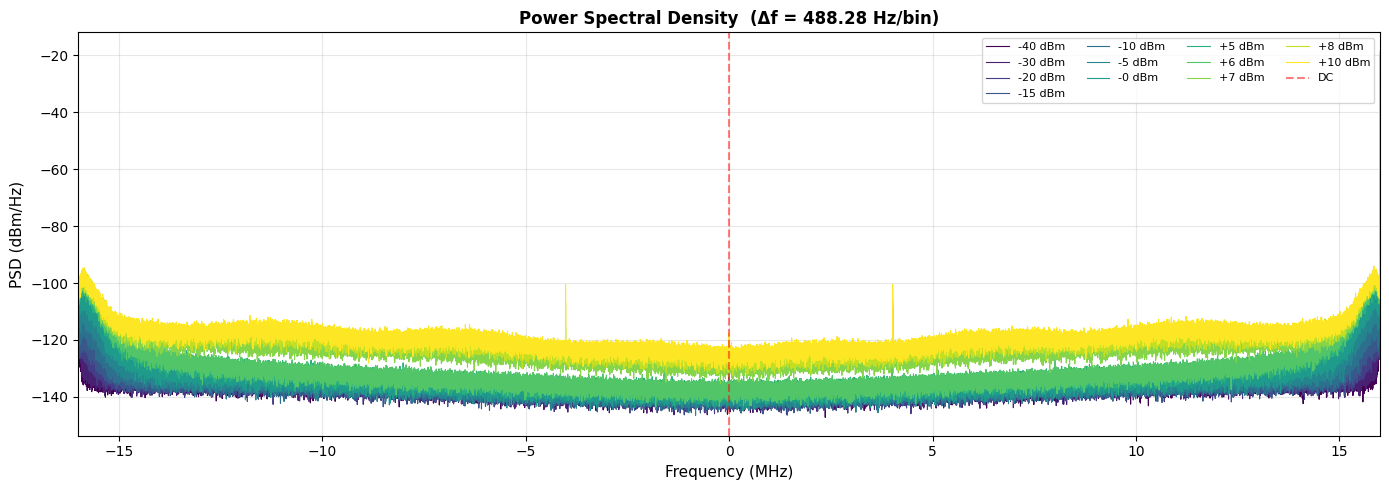

In [5]:
# ============================================================
# POWER SPECTRAL DENSITY
# ============================================================
# PSD[k] (dBm/Hz) = A_dBm[k] - 10*log10(df)
# where df = fs_out / N_fft  (frequency resolution)

PSD_offset_dB = 10 * np.log10(df)   # dB correction for bin bandwidth

fig_psd, ax_psd = plt.subplots(figsize=(14, 5))

for i, m in enumerate(measurements):
    A_dBm = m['A_dBFS'] + CAL_CONSTANT_FFT
    PSD_dBm_Hz = A_dBm - PSD_offset_dB
    ax_psd.plot(freq_axis / 1e6, PSD_dBm_Hz, color=colors[i], lw=0.8,
                label=f"{m['Pin_gen']:+.0f} dBm")

ax_psd.axvline(0, color='r', ls='--', lw=1.5, alpha=0.5, label='DC')
ax_psd.set_xlabel('Frequency (MHz)', fontsize=11)
ax_psd.set_ylabel('PSD (dBm/Hz)', fontsize=11)
ax_psd.set_title(f'Power Spectral Density  (Δf = {df:.2f} Hz/bin)', fontsize=12, fontweight='bold')
ax_psd.set_xlim([-fs_out/2/1e6, fs_out/2/1e6])
ax_psd.grid(True, alpha=0.3)
ax_psd.legend(fontsize=8, ncol=4, loc='upper right')

print(f"Frequency resolution: {df:.3f} Hz/bin")
print(f"PSD offset:           {PSD_offset_dB:.2f} dB  (= 10·log10({df:.2f} Hz))")
print(f"Example: tone at -20 dBm → PSD floor ≈ {{-20 - {PSD_offset_dB:.1f}:.1f}} dBm/Hz")

plt.tight_layout()
plt.savefig('images/fft_acc_PSD.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# ============================================================
# FINAL REPORT
# ============================================================
print(f"{'='*70}")
print("FINAL DIAGNOSTIC REPORT — FFT Accumulator")
print(f"{'='*70}")

print(f"\n FULL CHAIN GAIN BUDGET:")
print(f"  K_ADC (analog + ADC):              {K_ADC:.2f} dB   (Nb 01)")
print(f"  G_polyphase (D=8):                {G_polyphase:+.2f} dB   (Nb 02)")
print(f"  G_qout (qout=6):                  {G_qout:+.2f} dB   (Nb 02)")
print(f"  G_PFB_net:                        {G_PFB_net:+.2f} dB")
print(f"  G_CIC (R=8,M=1,N=3):            {CIC_GAIN_DB:+.2f} dB   (Nb 03)")
print(f"  G_QDATA (QSEL=14):               {G_QDATA_DB:+.2f} dB   (Nb 03)")
print(f"  FFT (unscaled, N={N_fft}):       0.00 dB   (cancelled by ÷N normalization)")

print(f"\n CALIBRATION CONSTANT PROGRESSION:")
print(f"  Nb 01  K_ADC:                {K_ADC:.2f} dB")
print(f"  Nb 02  CAL_CONSTANT_PRE:     {CAL_CONSTANT_PRE:.2f} dB   (+{CAL_CONSTANT_PRE-K_ADC:.2f} dB from PFB)")
print(f"  Nb 03  CAL_CONSTANT_POST:    {CAL_CONSTANT_POST:.2f} dB   (+{DDS_CIC_DELTA_DB:.2f} dB from DDS+CIC)")
print(f"  Nb 04  CAL_CONSTANT_FFT:     {CAL_CONSTANT_FFT:.2f} dB   (+0.00 dB from FFT)")

print(f"\n EMPIRICAL CALIBRATION:")
print(f"  Analytical: {CAL_CONSTANT_FFT_ANALYTICAL:.2f} dB")
print(f"  Empirical:  {CAL_CONSTANT_FFT:.2f} dB")
print(f"  Agreement:  {abs(CAL_CONSTANT_FFT-CAL_CONSTANT_FFT_ANALYTICAL):.2f} dB")
print(f"  Formula:    P_in (dBm) = A_dBFS + {CAL_CONSTANT_FFT:.2f}")
print(f"  Slope:      {slope:.4f}  (ideal = 1.0000)")

print(f"\n ACCURACY (linear region, Pin ≤ 0 dBm):")
print(f"  Mean error:   {np.mean(lin_errors):+.3f} dB")
print(f"  Std dev:       {np.std(lin_errors):.3f} dB")
print(f"  RMS error:     {np.sqrt(np.mean(np.array(lin_errors)**2)):.3f} dB")

print(f"\n SPECTRAL PARAMETERS:")
print(f"  FFT size:              N = {N_fft}")
print(f"  Sampling rate:         {fs_out/1e6:.0f} MHz")
print(f"  Frequency resolution:  {df:.3f} Hz/bin")
print(f"  Total bandwidth:       {fs_out/1e6:.0f} MHz")


FINAL DIAGNOSTIC REPORT — FFT Accumulator

 FULL CHAIN GAIN BUDGET:
  K_ADC (analog + ADC):              -12.89 dB   (Nb 01)
  G_polyphase (D=8):                +18.06 dB   (Nb 02)
  G_qout (qout=6):                  -36.12 dB   (Nb 02)
  G_PFB_net:                        -18.06 dB
  G_CIC (R=8,M=1,N=3):            +54.19 dB   (Nb 03)
  G_QDATA (QSEL=14):               -84.28 dB   (Nb 03)
  FFT (unscaled, N=65536):       0.00 dB   (cancelled by ÷N normalization)

 CALIBRATION CONSTANT PROGRESSION:
  Nb 01  K_ADC:                -12.89 dB
  Nb 02  CAL_CONSTANT_PRE:     30.95 dB   (+43.84 dB from PFB)
  Nb 03  CAL_CONSTANT_POST:    61.05 dB   (+30.09 dB from DDS+CIC)
  Nb 04  CAL_CONSTANT_FFT:     37.99 dB   (+0.00 dB from FFT)

 EMPIRICAL CALIBRATION:
  Analytical: 61.05 dB
  Empirical:  37.99 dB
  Agreement:  23.06 dB
  Formula:    P_in (dBm) = A_dBFS + 37.99
  Slope:      1.0368  (ideal = 1.0000)

 ACCURACY (linear region, Pin ≤ 0 dBm):
  Mean error:   +1.955 dB
  Std dev:       0.707

## 3. Summary

### Calibration at FFT Accumulator Output

The FFT (unscaled, N = 65536) adds no net offset to the calibration constant because the
$\times N$ amplitude gain is removed analytically during amplitude recovery. The calibration
constant is therefore the same as at the DDS+CIC output (Notebook 03):

$$P_{\text{in}}\,(\text{dBm}) = A_{\text{dBFS}} + \text{CAL\_CONSTANT\_FFT}$$

$$\text{CAL\_CONSTANT\_FFT} = \text{CAL\_CONSTANT\_POST} \approx 61\,\text{dB}$$

### Calibration constant progression across notebooks

| Notebook | Output point | CAL_CONSTANT | Delta from previous |
|---|---|---|---|
| 01 | ADC raw | $-K_{\text{ADC}} = 12.89$ dB | — |
| 02 | PFB output | $30.95$ dB | $+G_{\text{polyphase}} + G_{q_{\text{out}}} = -18.06$ dB (net PFB) |
| 03 | DDS+CIC output | $61.05$ dB | $-G_{\text{CIC}} - G_{\text{QDATA}} = +30.10$ dB |
| 04 | FFT acc output | $61.05$ dB | $0.00$ dB (FFT norm cancels FFT gain) |

### Mistake to avoid
Using `C_fft` as an opaque hardcoded constant disconnected from the DSP chain parameters
makes the calibration break silently when `qout` or `qprod` are changed. Always derive
`CAL_CONSTANT_FFT` from the full gain budget (as done in this notebook).
